In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


# Classificação de Espécies de Íris utilizando SVM

Neste trabalho será utilizado o Iris Dataset para realizar a classificação de três espécies de flores do gênero Iris.

O objetivo é analisar as características das flores e utilizar o algoritmo SVM (Support Vector Machine) para classificar cada amostra de acordo com sua espécie.

## 1. Importação das Bibliotecas

Nesta etapa serão importadas as bibliotecas necessárias para realizar a leitura dos dados, a análise exploratória, a preparação dos dados e a criação do modelo de classificação SVM.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## 2. Importação do Dataset

O dataset será carregado diretamente do arquivo Iris.csv disponibilizado no Kaggle.

In [6]:
# Carregando o dataset a partir do arquivo anexado pelo Kaggle
# Caminho confirmado a partir do output da Célula 3 (os.walk)
caminho_dataset = "/kaggle/input/datasets/menegidio/iris-species/Iris.csv"

df = pd.read_csv(caminho_dataset)

# Visualizando as primeiras linhas
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Análise Inicial dos Dados

Nesta etapa será feita uma análise inicial do dataset para verificar sua estrutura, quantidade de registros, tipos de dados e algumas informações estatísticas.

In [7]:
# Verificando as primeiras linhas do dataset
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### 3.1 Dimensões do Dataset

Primeiro, vamos verificar a quantidade de linhas e colunas presentes no dataset.

In [8]:
# Verificando a quantidade de linhas e colunas
print("Quantidade de linhas e colunas:", df.shape)

Quantidade de linhas e colunas: (150, 6)


### 3.2 Informações das Colunas

Agora será verificado o tipo de dado de cada coluna e se existem valores ausentes.

In [9]:
# Verificando informações sobre as colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


### 3.3 Estatísticas Descritivas

As estatísticas descritivas ajudam a entender a distribuição dos valores das características numéricas presentes no dataset.

In [10]:
# Exibindo estatísticas descritivas das colunas numéricas
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


### 3.4 Verificação de Valores Ausentes

Nesta etapa será verificado se existem valores ausentes nas colunas do dataset.

In [11]:
# Verificando valores ausentes
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

### 3.5 Distribuição das Espécies

Por fim, vamos verificar a quantidade de registros pertencentes a cada espécie de Iris.

In [12]:
# Contando a quantidade de registros de cada espécie
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## 4. Visualização dos Dados

Nesta etapa serão utilizados alguns gráficos para visualizar melhor as características das flores e observar as diferenças entre as espécies.

### 4.1 Quantidade de Amostras por Espécie

Primeiro, será apresentado um gráfico mostrando a quantidade de amostras de cada espécie presente no dataset.

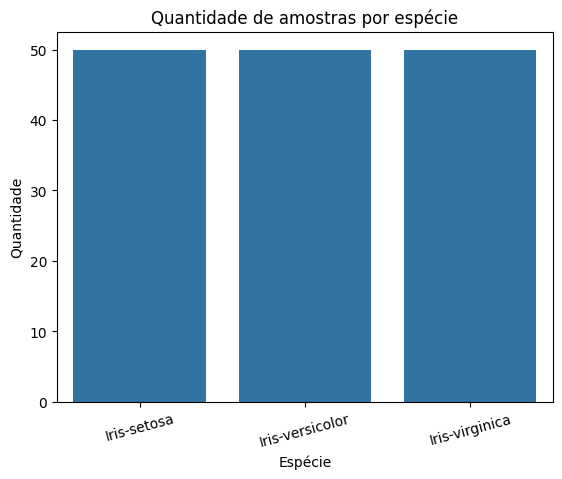

In [13]:
# Criando um gráfico com a quantidade de amostras por espécie
sns.countplot(data=df, x='Species')

plt.title('Quantidade de amostras por espécie')
plt.xlabel('Espécie')
plt.ylabel('Quantidade')
plt.xticks(rotation=15)

plt.show()

### 4.2 Relação entre o Comprimento e a Largura das Pétalas

O próximo gráfico apresenta a relação entre o comprimento e a largura das pétalas. As cores representam as diferentes espécies.

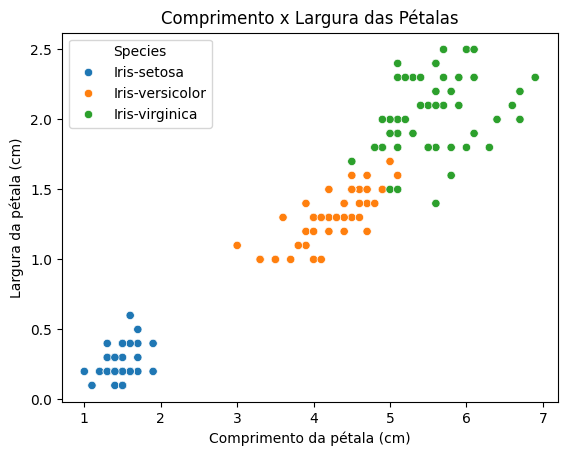

In [14]:
# Visualizando a relação entre o comprimento e a largura das pétalas
sns.scatterplot(
    data=df,
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='Species'
)

plt.title('Comprimento x Largura das Pétalas')
plt.xlabel('Comprimento da pétala (cm)')
plt.ylabel('Largura da pétala (cm)')

plt.show()

### 4.3 Distribuição das Medidas por Espécie

Agora serão utilizados gráficos de caixa para comparar a distribuição das quatro medidas entre as diferentes espécies.

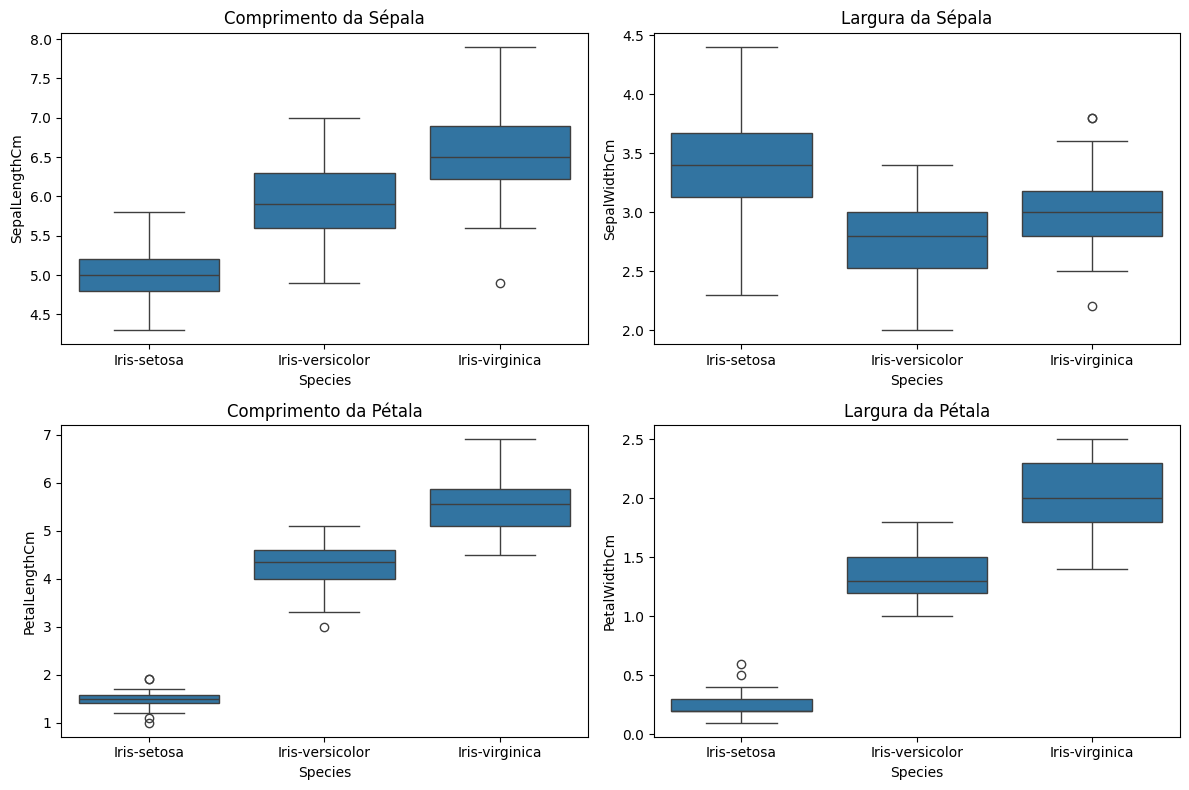

In [15]:
# Criando gráficos para comparar as medidas entre as espécies
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='Species', y='SepalLengthCm')
plt.title('Comprimento da Sépala')

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Species', y='SepalWidthCm')
plt.title('Largura da Sépala')

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Species', y='PetalLengthCm')
plt.title('Comprimento da Pétala')

plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='Species', y='PetalWidthCm')
plt.title('Largura da Pétala')

plt.tight_layout()
plt.show()

### 4.4 Análise das Visualizações

A partir dos gráficos, é possível observar que existem diferenças entre as espécies principalmente nas medidas das pétalas.

A espécie Iris-setosa apresenta medidas de pétalas menores em comparação com as outras espécies. Já Iris-versicolor e Iris-virginica apresentam valores mais próximos, embora também seja possível observar diferenças entre elas.

Essas características podem ser utilizadas pelo modelo SVM para realizar a classificação das espécies.

## 5. Preparação dos Dados

Antes de aplicar o modelo SVM, é necessário preparar os dados para o treinamento.

Nesta etapa serão selecionadas as características que serão utilizadas pelo modelo, separadas as variáveis de entrada e saída, divididos os dados entre treinamento e teste e realizada a padronização dos valores.

### 5.1 Separação das Variáveis

As quatro medidas das flores serão utilizadas como variáveis de entrada do modelo.

A coluna Species será utilizada como variável alvo, pois representa a espécie que o modelo deverá identificar.

In [16]:
# Separando as características das flores
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

# Separando a variável que queremos prever
y = df['Species']

# Conferindo os formatos dos dados
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (150, 4)
Formato de y: (150,)


### 5.2 Divisão dos Dados

Os dados serão divididos em duas partes:

- 80% dos dados serão utilizados para treinamento do modelo;
- 20% serão utilizados para testar o modelo.

A divisão será feita mantendo a mesma proporção das espécies nos dois grupos.

In [17]:
# Dividindo os dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Mostrando a quantidade de dados em cada grupo
print("Dados de treinamento:", X_train.shape)
print("Dados de teste:", X_test.shape)

Dados de treinamento: (120, 4)
Dados de teste: (30, 4)


### 5.3 Padronização dos Dados

A padronização é importante para o SVM porque as características possuem valores em escalas diferentes.

Será utilizado o StandardScaler para deixar as variáveis em uma escala semelhante antes de realizar o treinamento do modelo.

In [18]:
# Criando o padronizador
scaler = StandardScaler()

# Ajustando o padronizador apenas com os dados de treinamento
X_train_scaled = scaler.fit_transform(X_train)

# Aplicando a mesma transformação nos dados de teste
X_test_scaled = scaler.transform(X_test)

print("Padronização realizada com sucesso.")

Padronização realizada com sucesso.


## 6. Treinamento do Modelo SVM

Nesta etapa será criado o modelo de classificação utilizando o algoritmo SVM (Support Vector Machine).

O SVM busca encontrar uma separação entre as classes de dados, permitindo classificar as flores de acordo com suas características.

### 6.1 Criando o Modelo

Será utilizado o kernel RBF, que permite ao SVM trabalhar com relações não lineares entre os dados.

In [19]:
# Criando o modelo SVM
modelo_svm = SVC(kernel='rbf', random_state=42)

print("Modelo SVM criado com sucesso.")

Modelo SVM criado com sucesso.


### 6.2 Treinamento do Modelo

Agora o modelo será treinado utilizando os dados de treinamento que foram preparados anteriormente.

In [20]:
# Treinando o modelo SVM com os dados de treinamento
modelo_svm.fit(X_train_scaled, y_train)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


### 6.3 Realizando as Previsões

Depois do treinamento, o modelo será utilizado para fazer previsões sobre os dados que foram separados para teste.

In [21]:
# Fazendo previsões com os dados de teste
y_pred = modelo_svm.predict(X_test_scaled)

print("Previsões realizadas com sucesso.")

Previsões realizadas com sucesso.


## 7. Avaliação do Modelo

Após realizar o treinamento e as previsões, será feita a avaliação do modelo SVM.

Serão utilizadas métricas de classificação para verificar o desempenho do modelo nos dados de teste.

### 7.1 Acurácia

A acurácia representa a proporção de previsões que foram classificadas corretamente pelo modelo em relação ao total de amostras utilizadas no teste.

In [22]:
# Calculando a acurácia do modelo
acuracia = accuracy_score(y_test, y_pred)

print(f"Acurácia do modelo: {acuracia:.2f}")

Acurácia do modelo: 0.97


### 7.2 Relatório de Classificação

O relatório de classificação apresenta outras métricas importantes para avaliar o modelo, como precisão (precision), revocação (recall) e F1-score para cada espécie.

In [23]:
# Exibindo o relatório de classificação
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



### 7.3 Matriz de Confusão

A matriz de confusão permite visualizar a quantidade de previsões corretas e incorretas para cada uma das espécies.

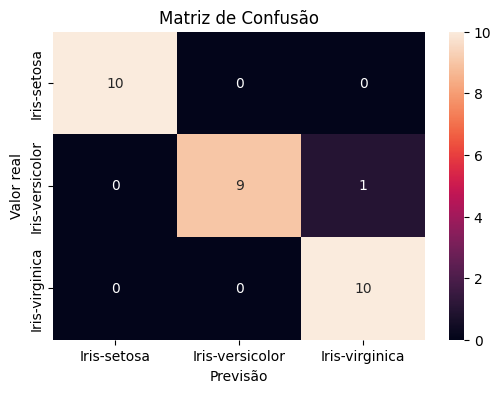

In [24]:
# Calculando a matriz de confusão
matriz = confusion_matrix(y_test, y_pred)

# Exibindo a matriz de confusão
plt.figure(figsize=(6, 4))

sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    xticklabels=modelo_svm.classes_,
    yticklabels=modelo_svm.classes_
)

plt.title('Matriz de Confusão')
plt.xlabel('Previsão')
plt.ylabel('Valor real')

plt.show()

### 7.4 Análise dos Resultados

O modelo SVM apresentou uma acurácia de 97% nos dados de teste.

A espécie Iris-setosa apresentou os melhores resultados, com precisão, recall e F1-score de 1,00.

Para Iris-versicolor, o recall foi de 0,90, enquanto para Iris-virginica a precisão foi de 0,91. Isso indica que houve uma pequena confusão entre essas duas espécies durante as previsões.

De forma geral, os resultados mostram que o modelo SVM conseguiu realizar a classificação das espécies com um bom desempenho.

### 7.5 Interpretação da Matriz de Confusão

A matriz de confusão permite comparar os valores reais das espécies com as previsões realizadas pelo modelo.

Os valores presentes na diagonal principal representam as classificações corretas. Os valores fora da diagonal representam os casos em que o modelo classificou uma amostra de forma diferente da sua espécie real.

## 8. Conclusão

Neste trabalho foi realizada a classificação de espécies de Iris utilizando o algoritmo SVM.

Inicialmente, foi realizada uma análise dos dados para conhecer a estrutura do dataset e verificar suas características. Em seguida, os dados foram preparados, divididos entre treinamento e teste e padronizados.

Após o treinamento do modelo SVM, foram realizadas previsões utilizando os dados de teste. O modelo apresentou uma acurácia de 97%, mostrando um bom desempenho na classificação das espécies.

A análise das métricas também mostrou bons resultados para as três espécies, com uma pequena dificuldade na diferenciação entre Iris-versicolor e Iris-virginica.

Com isso, o SVM apresentou um resultado satisfatório para a classificação das espécies presentes no Iris Dataset.